# KPI

## What will we calculate?

1. **Sharpe ratio**: It measures return per unit of risk taken.

Sharpe = (Portfolio Return - Risk Free Rate) / Standard Deviation of Returns

higher the better

*Answer*: For every unit of risk you took, how much extra return did you earn above doing nothing?

2. **CAGR** — Compound Annual Growth Rate: The smoothed annual return if growth had been perfectly steady.

*Answers*: what was the real annual return over the full period?

3. **Max Drawdown**: The largest peak-to-trough drop in the portfolio's history. 

If Nifty went from 12,000 to 7,500 during COVID, that's a 37.5% drawdown. 

*Answers*: What's the worst case an investor would have experienced?

Together these three tell the complete story of any investment:

- CAGR → reward

- Sharpe → reward per unit risk

- Max Drawdown → worst pain experienced




In [1]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn

In [2]:
import os

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create directory if it doesn't exist
os.makedirs('./output', exist_ok=True)

nifty = yf.download('^NSEI', start='2014-04-10', end='2026-03-10')
nifty.columns = nifty.columns.get_level_values(0)
nifty = nifty[['Close']]
nifty.index = pd.to_datetime(nifty.index)
nifty['returns'] = nifty['Close'].pct_change()

print(nifty.shape)
print(nifty.head(3))
print(nifty.tail(3))

[*********************100%***********************]  1 of 1 completed

(2927, 2)
Price             Close   returns
Date                             
2014-04-10  6796.399902       NaN
2014-04-11  6776.299805 -0.002957
2014-04-15  6733.100098 -0.006375
Price              Close   returns
Date                              
2026-03-05  24765.900391  0.011658
2026-03-06  24450.449219 -0.012737
2026-03-09  24028.050781 -0.017276


In [4]:
# ── CAGR ──────────────────────────────────────────────────────
start_price = nifty['Close'].iloc[0]
end_price   = nifty['Close'].iloc[-1]
start_date  = nifty.index[0]
end_date    = nifty.index[-1]

n_years = (end_date - start_date).days / 365.25

cagr = (end_price / start_price) ** (1 / n_years) - 1

print(f"Start price : ₹{start_price:,.0f}  ({start_date.date()})")
print(f"End price   : ₹{end_price:,.0f}  ({end_date.date()})")
print(f"Years       : {n_years:.2f}")
print(f"CAGR        : {cagr*100:.2f}%")

# ── SHARPE RATIO ──────────────────────────────────────────────
risk_free_rate_annual = 0.065        # India 10yr bond yield ~6.5%
risk_free_daily = risk_free_rate_annual / 252

returns_clean = nifty['returns'].dropna()

excess_returns = returns_clean - risk_free_daily
sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

print(f"\nRisk-free rate : {risk_free_rate_annual*100:.1f}% annual")
print(f"Sharpe Ratio   : {sharpe:.3f}")

# ── MAX DRAWDOWN ───────────────────────────────────────────────
rolling_max = nifty['Close'].cummax()
drawdown    = (nifty['Close'] - rolling_max) / rolling_max
max_dd      = drawdown.min()
max_dd_date = drawdown.idxmin()

print(f"\nMax Drawdown   : {max_dd*100:.2f}%")
print(f"Worst date     : {max_dd_date.date()}")

Start price : ₹6,796  (2014-04-10)
End price   : ₹24,028  (2026-03-09)
Years       : 11.91
CAGR        : 11.18%

Risk-free rate : 6.5% annual
Sharpe Ratio   : 0.354

Max Drawdown   : -38.44%
Worst date     : 2020-03-23


1. CAGR — Nifty went from ~6,800 to ~24,000 in 12 years. Roughly what annual return does that imply?
- it grew by around 1433.33 per year or around 21% annualyy
- your instinct was right direction but the math was off. You calculated simple growth (total gain / years) which gives 21%. CAGR uses compounding — each year's growth builds on the previous year's total, not the original. The correct answer is 11.18%. This is why CAGR is more honest than simple average return.
2. Max drawdown date — what event do you expect it to land near?
- Early 2020, the sharp drop

CAGR of 11.18% — solid. Nifty returned 11.18% annually on average over 12 years, beating inflation (avg ~5%) by a healthy margin.

Sharpe of 0.354 — modest. The rule of thumb: below 1 is acceptable, above 1 is good, above 2 is excellent. At 0.354, Nifty delivered low return per unit of risk. The volatility (especially COVID crash) dragged this down significantly.

Max drawdown of -38.44% — this is the number that keeps investors awake. Anyone who invested at the 2020 peak watched their portfolio drop 38% before recovery. Knowing this in advance is why drawdown matters for risk management.

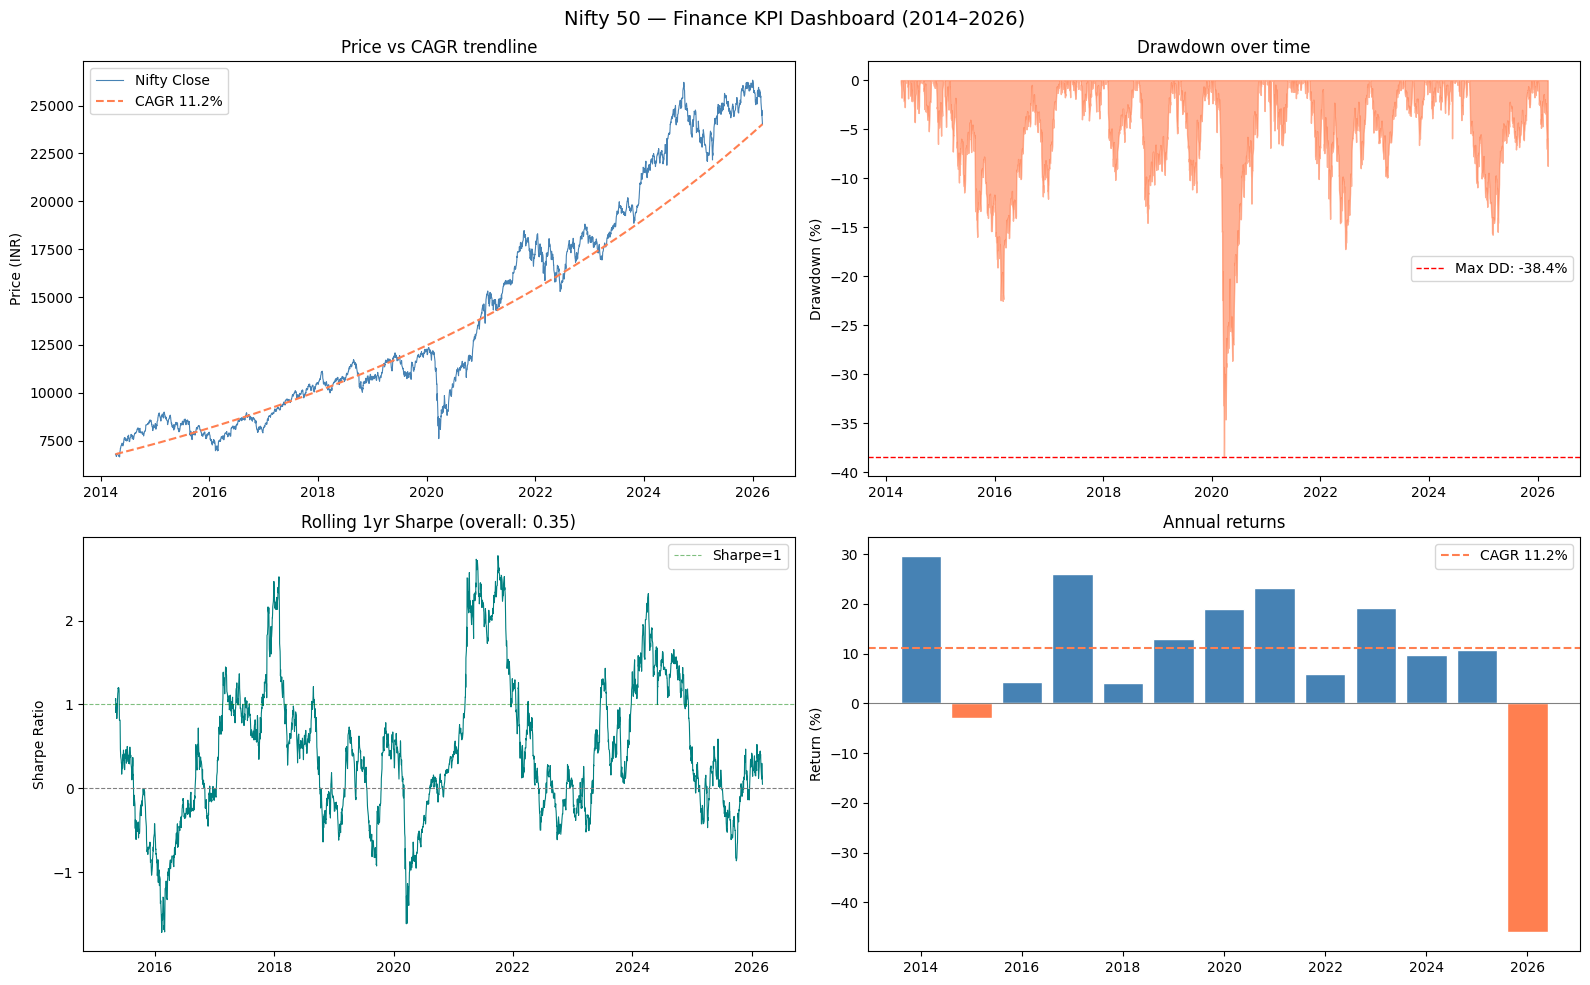

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Nifty 50 — Finance KPI Dashboard (2014–2026)', 
             fontsize=14)

# 1. Price + CAGR trendline
axes[0,0].plot(nifty.index, nifty['Close'], 
               color='steelblue', linewidth=0.8, label='Nifty Close')
# CAGR line
import numpy as np
days = (nifty.index - nifty.index[0]).days
cagr_line = start_price * (1 + cagr) ** (days / 365.25)
axes[0,0].plot(nifty.index, cagr_line, 
               color='coral', linewidth=1.5, 
               linestyle='--', label=f'CAGR {cagr*100:.1f}%')
axes[0,0].set_title('Price vs CAGR trendline')
axes[0,0].set_ylabel('Price (INR)')
axes[0,0].legend()

# 2. Drawdown chart
axes[0,1].fill_between(drawdown.index, drawdown * 100, 0,
                        color='coral', alpha=0.6)
axes[0,1].axhline(y=max_dd*100, color='red', 
                   linewidth=1, linestyle='--',
                   label=f'Max DD: {max_dd*100:.1f}%')
axes[0,1].set_title('Drawdown over time')
axes[0,1].set_ylabel('Drawdown (%)')
axes[0,1].legend()

# 3. Rolling Sharpe (252-day window)
rolling_excess = excess_returns.rolling(252)
rolling_sharpe = (rolling_excess.mean() / 
                  rolling_excess.std()) * np.sqrt(252)
axes[1,0].plot(rolling_sharpe.index, rolling_sharpe,
               color='teal', linewidth=0.8)
axes[1,0].axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
axes[1,0].axhline(y=1, color='green', linewidth=0.8, 
                   linestyle='--', alpha=0.5, label='Sharpe=1')
axes[1,0].set_title(f'Rolling 1yr Sharpe (overall: {sharpe:.2f})')
axes[1,0].set_ylabel('Sharpe Ratio')
axes[1,0].legend()

# 4. Annual returns bar chart
nifty['year'] = nifty.index.year
annual_ret = nifty.groupby('year')['returns'].mean() * 252
colors = ['steelblue' if x > 0 else 'coral' for x in annual_ret]
axes[1,1].bar(annual_ret.index, annual_ret * 100, 
              color=colors, edgecolor='white')
axes[1,1].axhline(y=0, color='gray', linewidth=0.8)
axes[1,1].axhline(y=cagr*100, color='coral', linewidth=1.5,
                   linestyle='--', label=f'CAGR {cagr*100:.1f}%')
axes[1,1].set_title('Annual returns')
axes[1,1].set_ylabel('Return (%)')
axes[1,1].legend()
nifty = nifty.drop(columns=['year'])

plt.tight_layout()
plt.savefig('./output/kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

1. In the rolling Sharpe chart — when did Nifty have its best risk-adjusted returns?
- 2018, 2022, 2024

2. In the drawdown chart — how long did it take to recover from the COVID crash approximately?
- nearly an year it seems to be around 2021 that market came back to 0

3. Which year had the worst annual return and which had the best?
- worst: 2026 (2 months in tho), otherwise it seems 2015
- best: 2014